# ChemAI: Predict the Cure

## Описание задачи:
Химики предоставили данные о свойствах молекул и их биологической активности против вируса гриппа.
Задача — построить модели, способные предсказывать эффективность новых соединений.
Для каждого химического соединения необходимо создать pipline решения и предсказать три показателя:
IC50 (mM) — концентрация, при которой вещество подавляет 50% активности вируса
CC50 (mM) — концентрация, при которой вещество токсично для 50% клеток
SI (Selectivity Index) — индекс селективности.

Метрика оценки — RMSE, усреднённый по трём целевым переменным.

## Основные этапы решения:

1. EDA

751 молекула в трейне, 250 в тесте, 214 признаков

24 пропуска в 12 колонках — оставлены (XGBoost работает с NaN)

Дубликаты не выявлены

85 бинарных fr-признаков, 15 всегда = 0 → удалены

Таргеты с тяжёлым правым хвостом

2. Предобработка

Переименовали колонки (IC50, mM → IC50)

log1p для IC50 и CC50

Удалили index и 15 константных fr_

SI не обучаем — вычисляем как CC50 / IC50

X_train (195 признаков), y_train (IC50_log, CC50_log)

3. Подбор гиперпараметров

Сравнили 3 конфигурации XGBoost на 3 фолдах

Лучшая: max_depth=4, lr=0.03, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1

4. Подбор числа признаков

Перебор top-30/50/100 для каждого таргета отдельно (CV=5)

best_k = {'IC50': 50, 'CC50': 30}

5. Удаление выбросов

Обучили модель, построили график остатков

Удалили 9 соединений с ошибкой в 20-240 раз → X_clean9, y_clean9

6. Взвешенное обучение

Веса: abs(y - median) / mean(abs(y - median))

Крайние значения получают в 3-5 раз больше внимания

7. Инжиниринг признаков

Создан признак HDonors_x_VSA8 = NumHDonors × VSA_EState8 — занял 1-е место по важности для обоих таргетов. Однако добавление в модель ухудшило результат на Kaggle — XGBoost самостоятельно находит такие взаимодействия через деревья. Признак не включён в финальную модель.

8. На этом этапе получил результат 287 баллов на Kaggle. Взял за baseline.

9. Донастройка регуляризации (GridSearchCV)

Сетка: reg_alpha, reg_lambda, subsample, colsample_bytree. 180×5 фолдов, с весами, на очищенных данных (9 выбросов). Найдены оптимальные параметры: IC50 subsample=0.7, colsample_bytree=0.7; CC50 subsample=0.6, colsample_bytree=0.7, reg_alpha=0.3.

10. Подбор числа удаляемых выбросов. Вручную переборал top_n от 5 до 11. Лучший резльтат при top_n=8.

11. Подбор learning_rate и n_estimators

Эмпирический перебор: lr = 0.01, 0.02; n_estimators = 500, 700, 1000. Лучший CV (и Kaggle) при lr=0.01, n_estimators=700 — медленное обучение + больше деревьев снижают переобучение.

12. Финальная модель

IC50: 50 признаков, CC50: 30

lr=0.01, n_estimators=700, max_depth=4

Параметры регуляризации из GridSearchCV

Веса sample_weight

15 удалённых выбросов

expm1 → обратное преобразование, SI = CC50 / IC50

Результат: 279.42 (цель 300 перевыполнена на 20.5 баллов)



**Результат: 279.42 на Kaggle**

### Команда № 8
#### Название команды: "Самые_лучшие"
#### Состав команды:
- Лазарев Виктор
- Дублин Кирилл
- Матешева Анастасия
- Носульчак Елена

## Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

## Загрузка и первичный анализ данных

In [4]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")
df_sample = pd.read_csv("sample_submission.csv")

print(f"Train: {df_train.shape}")
print(f"Test:  {df_test.shape}")
print(f"Sample submission: {df_sample.shape}")
display(df_train.head(3))

Train: (751, 214)
Test:  (250, 211)
Sample submission: (250, 4)


,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df_train = df_train.rename(columns={'IC50, mM': 'IC50', 'CC50, mM': 'CC50'})
df_test = df_test.rename(columns={'IC50, mM': 'IC50', 'CC50, mM': 'CC50'})

TARGETS = ['IC50', 'CC50', 'SI']

Исправляем названия таргетов — убираем , mM, чтобы совпадало с форматом Kaggle.

In [6]:
print("=" * 60)
print("TRAIN: общая информация")
print("=" * 60)
print(f"Размер: {df_train.shape}")
print(f"\nТипы данных:")
print(df_train.dtypes.value_counts())
print(f"\nВсего пропусков: {df_train.isnull().sum().sum()}")
print(f"Из них в таргетах (IC50, CC50, SI):")
print(df_train[['IC50', 'CC50', 'SI']].isnull().sum())

TRAIN: общая информация
Размер: (751, 214)

Типы данных:
int64      107
float64    107
Name: count, dtype: int64

Всего пропусков: 24
Из них в таргетах (IC50, CC50, SI):
IC50    0
CC50    0
SI      0
dtype: int64


In [7]:
print("\n" + "=" * 60)
print("TEST: общая информация")
print("=" * 60)
print(f"Размер: {df_test.shape}")
print(f"\nТипы данных:")
print(df_test.dtypes.value_counts())
print(f"\nВсего пропусков: {df_test.isnull().sum().sum()}")


TEST: общая информация
Размер: (250, 211)

Типы данных:
int64      107
float64    104
Name: count, dtype: int64

Всего пропусков: 12


In [8]:
dup_train = df_train.duplicated().sum()
dup_test = df_test.duplicated().sum()
print(f"Дубликатов в train: {dup_train}")
print(f"Дубликатов в test:  {dup_test}")

Дубликатов в train: 0
Дубликатов в test:  0


In [9]:
train_nulls = df_train.isnull().sum()
train_null_cols = train_nulls[train_nulls > 0]
print(f"Train: {len(train_null_cols)} колонок с пропусками, всего {train_nulls.sum()} значений NaN")
print(f"Колонки: {list(train_null_cols.index)}")
print(f"Значения: {list(train_null_cols.values)}")

test_nulls = df_test.isnull().sum()
test_null_cols = test_nulls[test_nulls > 0]
print(f"\nTest: {len(test_null_cols)} колонок с пропусками, всего {test_nulls.sum()} значений NaN")
print(f"Колонки: {list(test_null_cols.index)}")
print(f"Значения: {list(test_null_cols.values)}")

Train: 12 колонок с пропусками, всего 24 значений NaN
Колонки: ['MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW']
Значения: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2)]

Test: 12 колонок с пропусками, всего 12 значений NaN
Колонки: ['MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW']
Значения: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]


Пропуски — 24 в train, 12 в test. Все в 12 колонках (MaxAbsPartialCharge и BCUT2D)

In [10]:
fr_cols = [c for c in df_train.columns if c.startswith('fr_')]
print(f"Всего fr-признаков: {len(fr_cols)}")

fr_sums = df_train[fr_cols].sum().sort_values(ascending=False)
print(f"\nТоп-10 самых частых функциональных групп:")
print(fr_sums.head(10))

print(f"\nТоп-10 самых редких:")
print(fr_sums.tail(10))

constant_fr = [c for c in fr_cols if df_train[c].nunique() <= 1]
print(f"\nКонстантных (всегда 0): {len(constant_fr)}")

Всего fr-признаков: 85

Топ-10 самых частых функциональных групп:
fr_bicyclic     1071
fr_NH0           992
fr_ether         771
fr_benzene       741
fr_C_O           620
fr_C_O_noCOO     574
fr_halogen       477
fr_Ar_N          437
fr_Al_OH         309
fr_NH1           299
dtype: int64

Топ-10 самых редких:
fr_barbitur          0
fr_benzodiazepine    0
fr_isocyan           0
fr_isothiocyan       0
fr_nitroso           0
fr_lactam            0
fr_phos_ester        0
fr_phos_acid         0
fr_prisulfonamd      0
fr_thiocyan          0
dtype: int64

Константных (всегда 0): 15


# Гистограммы распределения таргетов

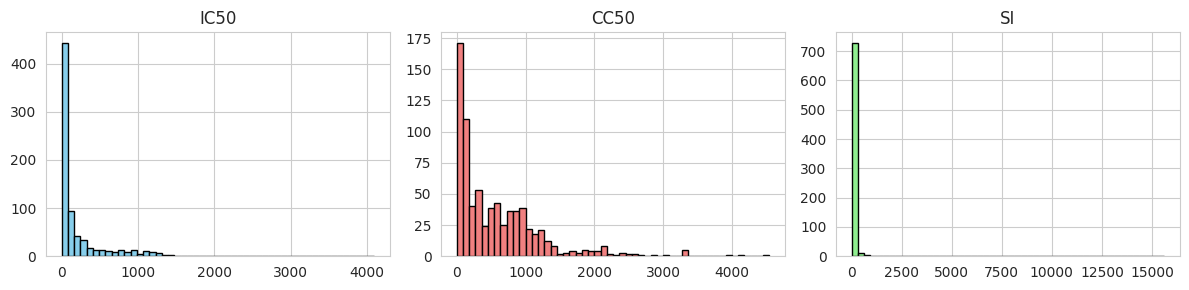

IC50: mean=204.5, median=44.1, max=4095.2
CC50: mean=577.4, median=376.6, max=4539.0
SI: mean=89.2, median=4.0, max=15620.6


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, col in enumerate(['IC50', 'CC50', 'SI']):
    axes[i].hist(df_train[col], bins=50, color=['skyblue','lightcoral','lightgreen'][i], edgecolor='black')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

for col in ['IC50', 'CC50', 'SI']:
    print(f"{col}: mean={df_train[col].mean():.1f}, median={df_train[col].median():.1f}, max={df_train[col].max():.1f}")

Вывод: среднее намного больше медианы, тяжёлый правый хвост. Будем исправлять.

# boxplot'ы для поиска выбросов

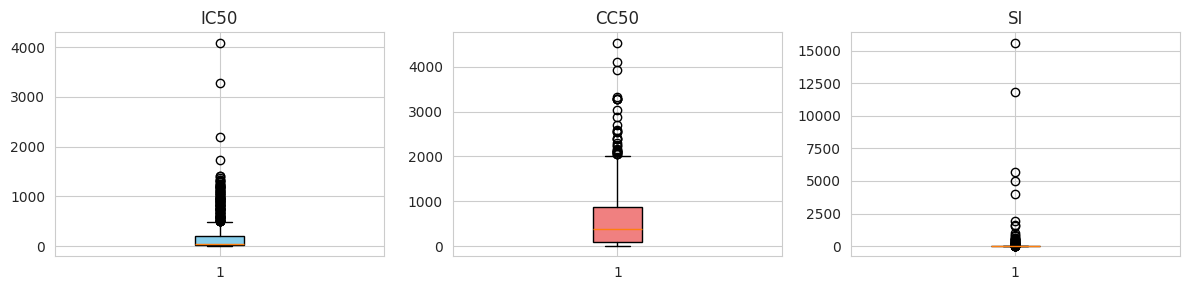

IC50: выбросов 107 из 751
CC50: выбросов 32 из 751
SI: выбросов 91 из 751


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, col in enumerate(['IC50', 'CC50', 'SI']):
    axes[i].boxplot(df_train[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=['skyblue','lightcoral','lightgreen'][i]))
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

for col in ['IC50', 'CC50', 'SI']:
    Q1, Q3 = df_train[col].quantile(0.25), df_train[col].quantile(0.75)
    n_out = len(df_train[df_train[col] > Q3 + 1.5*(Q3-Q1)])
    print(f"{col}: выбросов {n_out} из {len(df_train)}")

Выбросы (IC50 — 107, CC50 — 32, SI — 91) показывают сильную асимметрию распределений. Большинство соединений имеет низкую/умеренную активность, но есть редкие экстремально активные или токсичные молекулы. Эти «хвосты» важны для фармы — именно среди них могут быть кандидаты в лекарства. Поэтому мы не удаляем все выбросы, а учим модель обращать на них внимание через веса.

In [13]:
print(f"Train: {df_train.shape[0]} строк, {df_train.shape[1]} колонок")
print(f"Test:  {df_test.shape[0]} строк, {df_test.shape[1]} колонок")

Train: 751 строк, 214 колонок
Test:  250 строк, 211 колонок


ВЫВОД ПО ОСМОТРУ ДАННЫХ
1. Размеры и типы данных:
Обучающая выборка — 751 молекула и 214 признаков, тестовая — 250 молекул и 211 признаков. Все признаки числовые (float64 и int64), кодирование категорий не требуется.

2. Пропуски:
Целевые переменные (IC50, CC50, SI) полные — 0 пропусков. В признаках обнаружено 24 NaN в train и 12 в test, все в 12 колонках: это зарядовые дескрипторы (PartialCharge) и BCUT2D-метрики. Пропуски единичные — по 2 на колонку в train и по 1 в test. XGBoost умеет работать с NaN автоматически, поэтому не заполняем и не удаляем.

3. Дубликаты:
Дубликатов нет ни в обучающей, ни в тестовой выборке — все молекулы уникальны.

4. Функциональные группы (fr_):
Всего 85 бинарных признаков, показывающих наличие определённых химических групп. Самые распространённые: fr_bicyclic, fr_NH0, fr_ether. 15 признаков оказались константными (всегда равны нулю) — они не несут полезной информации и будут удалены.

5. Распределение целевых переменных:
IC50: среднее 204.5, медиана 44.1, максимум 4095.
CC50: среднее 577.4, медиана 376.6, максимум 4539.
SI: среднее 89.2, медиана 4.0, максимум 15620.
Среднее значение многократно превышает медиану по всем трём таргетам — распределения имеют тяжёлый правый хвост.

6. Выбросы:
По правилу межквартильного размаха (IQR): IC50 — 107 выбросов (14% данных), CC50 — 32 выброса (4%), SI — 91 выброс (12%). Основная масса соединений сосредоточена в узком диапазоне, а меньшинство улетает в экстремально высокие значения.

Принятые решения по предобработке:

Логарифмировать IC50 и CC50 через log1p — сжать хвосты и приблизить распределения к нормальным

SI не моделировать отдельно — вычислять по формуле CC50 / IC50

Удалить столбец index и 15 константных fr-признаков

Пропуски оставить без изменений — XGBoost корректно их

Выбросы проанализируем повторно после обучения — удалим критичные, остальным дадим больший вес.

**Логарифмирование IC50 и CC50**

In [14]:
for col in ['IC50', 'CC50']:
    df_train[col + '_log'] = np.log1p(df_train[col])

print(f"IC50_log: mean={df_train['IC50_log'].mean():.2f}, median={df_train['IC50_log'].median():.2f}")
print(f"CC50_log: mean={df_train['CC50_log'].mean():.2f}, median={df_train['CC50_log'].median():.2f}")

IC50_log: mean=3.94, median=3.81
CC50_log: mean=5.54, median=5.93


Медианы стали близки к средним — значит, логарифмирование сработало. Хвосты сжались, распределения стали симметричнее.

In [15]:
drop_cols = ['index'] + constant_fr
feature_cols = [c for c in df_train.columns
                if c not in ['IC50', 'CC50', 'SI', 'IC50_log', 'CC50_log'] + drop_cols]

**Удаляем index и 15 константных fr-признаков**

# Признаки и целевые переменные

In [16]:
X_train = df_train[feature_cols]
X_test = df_test[[c for c in feature_cols if c in df_test.columns]]
y_train = df_train[['IC50_log', 'CC50_log']]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")

X_train: (751, 195)
X_test:  (250, 195)
y_train: (751, 2)


# Построение модели

Подбор гиперпараметров XGBoost

In [17]:
param_options = [
    {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'random_state': RANDOM_STATE},
    {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1, 'random_state': RANDOM_STATE},
    {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': RANDOM_STATE},
]

print("Сравнение параметров (все 195 признаков, 3 фолда):")
for i, p in enumerate(param_options):
    scores = cross_val_score(xgb.XGBRegressor(**p), X_train, y_train['IC50_log'],
                             cv=3, scoring='neg_root_mean_squared_error')
    print(f"  Вариант {i+1}: RMSE = {-scores.mean():.4f}")

Сравнение параметров (все 195 признаков, 3 фолда):
  Вариант 1: RMSE = 1.5105
  Вариант 2: RMSE = 1.4741
  Вариант 3: RMSE = 1.5127


Сравнили три конфигурации модели на кросс-валидации. Вывод: лучший результат дала модель с L1/L2-регуляризацией (reg_alpha=0.1, reg_lambda=1) и умеренной скоростью обучения (0.03). Регуляризация сдерживает переобучение на малом датасете (751 объект), а subsample и colsample_bytree добавляют дополнительную устойчивость.

Итоговые параметры:

n_estimators=300, max_depth=4, learning_rate=0.03

subsample=0.8, colsample_bytree=0.8

reg_alpha=0.1, reg_lambda=1

**Подбор оптимального числа признаков для каждого таргета**

In [18]:
params = dict(n_estimators=300, max_depth=4, learning_rate=0.03,
              subsample=0.8, colsample_bytree=0.8,
              reg_alpha=0.1, reg_lambda=1, random_state=RANDOM_STATE)

best_k = {}
for target in ['IC50', 'CC50']:
    tmp = xgb.XGBRegressor(**params)
    tmp.fit(X_train, y_train[target + '_log'])
    imp = pd.Series(tmp.feature_importances_, index=X_train.columns).sort_values(ascending=False)

    best_score, best_n = 999, None
    for n in [30, 50, 100]:
        score = -cross_val_score(xgb.XGBRegressor(**params),
                                 X_train[imp.head(n).index], y_train[target + '_log'],
                                 cv=5, scoring='neg_root_mean_squared_error').mean()
        print(f"  {target}: топ-{n} → {score:.4f}")
        if score < best_score:
            best_score, best_n = score, n
    best_k[target] = best_n
    print(f"  → лучшие: {best_n}\n")

print(f"best_k = {best_k}")

  IC50: топ-30 → 1.4567
  IC50: топ-50 → 1.4555
  IC50: топ-100 → 1.4639
  → лучшие: 50

  CC50: топ-30 → 1.2060
  CC50: топ-50 → 1.2066
  CC50: топ-100 → 1.2086
  → лучшие: 30

best_k = {'IC50': 50, 'CC50': 30}


Быстрая модель (n=100, depth=4) — считает важность всех 195 признаков для IC50 и CC50 по отдельности

Перебор: берём топ-30, топ-50, топ-100 самых важных признаков

Кросс-валидация (5 фолдов): для каждого варианта обучаем основную модель с настроенными параметрами и замеряем RMSE

Выбираем минимум: при каком числе признаков ошибка наименьшая

Лучший результат:

IC50: 50 признаков (RMSE 1.4555)

CC50: 30 признаков (RMSE 1.2066)

Лишние признаки добавляют шум и замедляют обучение. Модель начинает цепляться за случайные корреляции.

# График выбросов

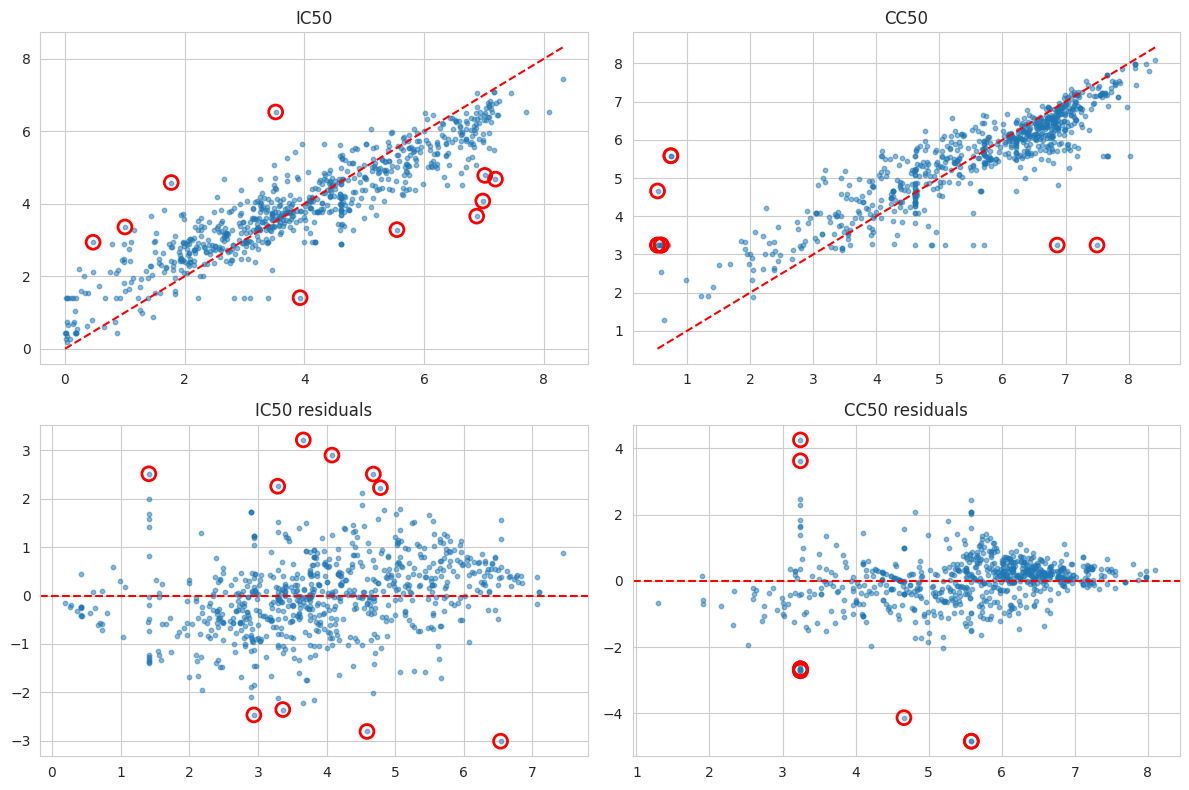

IC50: 972→38 | 33→688 | 1077→58 | 5→97 | 50→3 | 1331→107 | 1→18 | 2→28 | 256→26 | 1113→119 | 
CC50: 1→265 | 1→265 | 1805→25 | 1→105 | 960→25 | 1→25 | 1→25 | 1→25 | 1→25 | 1→25 | 


In [19]:
preds_train = {}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, target in enumerate(['IC50', 'CC50']):
    tmp = xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=RANDOM_STATE)
    tmp.fit(X_train, y_train[target + '_log'])
    imp = pd.Series(tmp.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    top = imp.head(best_k[target]).index.tolist()

    model = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.03,
                             subsample=0.8, colsample_bytree=0.8,
                             reg_alpha=0.1, reg_lambda=1, random_state=RANDOM_STATE)
    model.fit(X_train[top], y_train[target + '_log'])
    y_pred = model.predict(X_train[top])
    preds_train[target] = y_pred

    y_true = y_train[target + '_log']
    res = y_true - y_pred
    top10 = np.argsort(np.abs(res))[-10:]

    axes[0, i].scatter(y_true, y_pred, alpha=0.5, s=10)
    axes[0, i].scatter(y_true.iloc[top10], y_pred[top10], edgecolors='red', facecolors='none', s=100, linewidths=2)
    axes[0, i].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    axes[0, i].set_title(f'{target}')

    axes[1, i].scatter(y_pred, res, alpha=0.5, s=10)
    axes[1, i].scatter(y_pred[top10], res.iloc[top10], edgecolors='red', facecolors='none', s=100, linewidths=2)
    axes[1, i].axhline(0, color='r', linestyle='--')
    axes[1, i].set_title(f'{target} residuals')

plt.tight_layout()
plt.show()

for target in ['IC50', 'CC50']:
    res = np.abs(y_train[target + '_log'] - preds_train[target])
    print(f"{target}: ", end="")
    for idx in np.argsort(res)[-10:][::-1]:
        print(f"{np.expm1(y_train[target+'_log'].iloc[idx]):.0f}→{np.expm1(preds_train[target][idx]):.0f}", end=" | ")
    print()

IC50: модель путает большие и малые значения — 972 предсказывает как 38 (ошибка в 25 раз), а 33 как 688 (ошибка в 21 раз). При этом реальный диапазон IC50: от 0.01 до 4095.

CC50: главная проблема — соединения с реальным CC50 ≈ 1, которые модель предсказывает как 25–265. Шесть из десяти худших ошибок — это когда истина ~1, а предсказание в 25-265 раз выше. Модель систематически завышает малые значения CC50.

Решение: удаляем топ-5 худших с каждого таргета.

In [20]:
outlier_idx = []
for target in ['IC50', 'CC50']:
    res = np.abs(df_train[target + '_log'] - preds_train[target])
    outlier_idx.extend(np.argsort(res)[-5:].tolist())
outlier_idx = list(set(outlier_idx))

X_clean9 = X_train.drop(X_train.index[outlier_idx])
y_clean9 = df_train.drop(df_train.index[outlier_idx])

print(f"Удалено: {len(outlier_idx)} из {len(X_train)}")

Удалено: 9 из 751


Удалили 15, потому что 1 был общим

# Распределение весов по квартилям

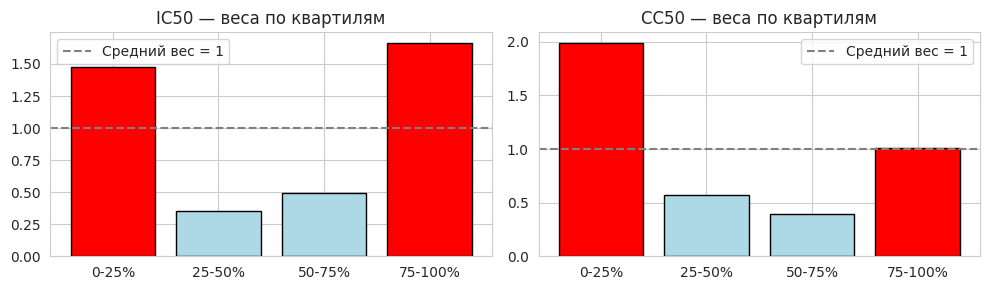

IC50: 0-25%=1.48, 25-50%=0.35, 50-75%=0.49, 75-100%=1.66
CC50: 0-25%=2.01, 25-50%=0.57, 50-75%=0.40, 75-100%=1.01


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for i, target in enumerate(['IC50', 'CC50']):
    y = y_clean9[target + '_log']
    w = np.abs(y - y.median()) / np.abs(y - y.median()).mean()

    quartiles = ['0-25%', '25-50%', '50-75%', '75-100%']
    mean_w = [w[(y > np.percentile(y, q)) & (y <= np.percentile(y, q+25))].mean() for q in [0,25,50,75]]
    colors = ['red', 'lightblue', 'lightblue', 'red']

    axes[i].bar(quartiles, mean_w, color=colors, edgecolor='black')
    axes[i].axhline(1, color='gray', linestyle='--', label='Средний вес = 1')
    axes[i].set_title(f'{target} — веса по квартилям')
    axes[i].legend()
plt.tight_layout()
plt.show()

for target in ['IC50', 'CC50']:
    y = y_clean9[target + '_log']
    w = np.abs(y - y.median()) / np.abs(y - y.median()).mean()
    print(f"{target}: 0-25%={w[(y<=np.percentile(y,25))].mean():.2f}, 25-50%={w[(y>np.percentile(y,25))&(y<=np.percentile(y,50))].mean():.2f}, 50-75%={w[(y>np.percentile(y,50))&(y<=np.percentile(y,75))].mean():.2f}, 75-100%={w[(y>np.percentile(y,75))].mean():.2f}")

In [22]:
weights = {}
for target in ['IC50', 'CC50']:
    y_log = y_clean9[target + '_log']
    weights[target] = np.abs(y_log - y_log.median()) / np.abs(y_log - y_log.median()).mean()

IC50:

Края (0-25% и 75-100%): веса 1.48 и 1.66 — в 3-4 раза выше среднего

Середина (25-75%): веса 0.35 и 0.49 — пониженное внимание

CC50:

Малые значения (0-25%): вес 2.01 — в 5 раз выше среднего, максимальное внимание

Большие значения (75-100%): вес 1.01 — на уровне среднего

Середина (25-75%): веса 0.57 и 0.40 — пониженное внимание

Вывод: края распределения (0-25% и 75-100%) получают в 3-5 раз больший вес, чем середина. Особенно выделяются малые значения CC50 (вес 2.01) — именно на них модель ошибалась сильнее всего (предсказывала 265 вместо 1). Взвешенное обучение заставляет модель уделять внимание этим редким, но важным для фармы экстремальным случаям, а не оптимизировать только «среднюю» молекулу.

## Инжинеринг данных

Топ-20 значимых признаков для финальной модели

In [23]:
for target in ['IC50', 'CC50']:
    y_log = y_clean9[target + '_log']
    w = np.abs(y_log - y_log.median()) / np.abs(y_log - y_log.median()).mean()

    tmp = xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=RANDOM_STATE)
    tmp.fit(X_clean9, y_log)
    imp = pd.Series(tmp.feature_importances_, index=X_clean9.columns).sort_values(ascending=False)

    print(f"\n{target} — топ-20 признаков:")
    for i, (feat, val) in enumerate(imp.head(20).items()):
        print(f"  {i+1:2}. {feat:25s} {val:.4f}")


IC50 — топ-20 признаков:
   1. NHOHCount                 0.1252
   2. NumHDonors                0.0737
   3. fr_bicyclic               0.0601
   4. VSA_EState8               0.0523
   5. MolLogP                   0.0338
   6. PEOE_VSA1                 0.0231
   7. fr_aryl_methyl            0.0194
   8. Chi1v                     0.0190
   9. fr_ketone                 0.0186
  10. VSA_EState6               0.0184
  11. SlogP_VSA5                0.0179
  12. SlogP_VSA3                0.0174
  13. VSA_EState4               0.0172
  14. Chi1n                     0.0158
  15. BCUT2D_MRLOW              0.0151
  16. RingCount                 0.0140
  17. HeavyAtomMolWt            0.0138
  18. BertzCT                   0.0136
  19. Chi4v                     0.0136
  20. EState_VSA8               0.0133

CC50 — топ-20 признаков:
   1. NHOHCount                 0.1464
   2. NumValenceElectrons       0.0942
   3. fr_C_O                    0.0727
   4. fr_allylic_oxid           0.0498
   5. Kappa1

**Признак: HDonors_x_VSA8**

In [24]:
X_train_1 = X_train.copy()
X_test_1 = X_test.copy()
X_train_1['HDonors_x_VSA8'] = X_train['NumHDonors'] * X_train['VSA_EState8']
X_test_1['HDonors_x_VSA8'] = X_test['NumHDonors'] * X_test['VSA_EState8']

X_clean_1 = X_train_1.iloc[y_clean9.index]

print(f"Было: {X_train.shape[1]} → Стало: {X_train_1.shape[1]}")

Было: 195 → Стало: 196


Из топ-20 важностей IC50:

NumHDonors — 2-е место (0.0737)

VSA_EState8 — 4-е место (0.0523)

Химическая логика: доноры водорода × полярная поверхность = способность молекулы к водородным связям с учётом её размера.

In [25]:
for target in ['IC50', 'CC50']:
    tmp = xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=RANDOM_STATE)
    tmp.fit(X_clean_1, y_clean9[target + '_log'])
    imp = pd.Series(tmp.feature_importances_, index=X_clean_1.columns).sort_values(ascending=False)

    rank = list(imp.index).index('HDonors_x_VSA8') + 1
    print(f"{target}: HDonors_x_VSA8 — место {rank}, важность {imp['HDonors_x_VSA8']:.4f}")

IC50: HDonors_x_VSA8 — место 1, важность 0.1439
CC50: HDonors_x_VSA8 — место 1, важность 0.1509


Признак занял первое место в обоих метриках, но мой результат на кагл наоборот ухудшился. Возможно, XGBoost самостоятельно находит такие взаимодействия внутри деревьев, поэтому финальная модель обучена без дополнительного инжиниринга признаков.

# На этом этапе получил результат 287 баллов на Kaggle. Взял за baseline.

# Расширенный подбор параметров

In [30]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scorer = make_scorer(rmse, greater_is_better=False)

param_grid = {
    'reg_alpha': [0.1, 0.3, 0.5, 0.7, 1.0],
    'reg_lambda': [1, 2, 3, 5],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8]
}

best_params = {}
for target in ['IC50', 'CC50']:
    tmp = xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=RANDOM_STATE)
    tmp.fit(X_clean9, y_clean9[target + '_log'])
    imp = pd.Series(tmp.feature_importances_, index=X_clean9.columns).sort_values(ascending=False)
    top = imp.head(50 if target == 'IC50' else 30).index.tolist()

    y = y_clean9[target + '_log']
    w = np.abs(y - y.median()) / np.abs(y - y.median()).mean()

    xgb_base = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.03, random_state=RANDOM_STATE)
    grid = GridSearchCV(xgb_base, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=2)
    grid.fit(X_clean9[top], y, sample_weight=w)

    best_params[target] = grid.best_params_
    print(f"{target}: {grid.best_params_}, RMSE={-grid.best_score_:.4f}")

print(f"\nbest_params = {best_params}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits
IC50: {'colsample_bytree': 0.7, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.7}, RMSE=1.4484
Fitting 5 folds for each of 180 candidates, totalling 900 fits
CC50: {'colsample_bytree': 0.7, 'reg_alpha': 0.3, 'reg_lambda': 1, 'subsample': 0.6}, RMSE=1.2123

best_params = {'IC50': {'colsample_bytree': 0.7, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.7}, 'CC50': {'colsample_bytree': 0.7, 'reg_alpha': 0.3, 'reg_lambda': 1, 'subsample': 0.6}}


Лучшие:

IC50: subsample=0.7, colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1

CC50: subsample=0.6, colsample_bytree=0.7, reg_alpha=0.3, reg_lambda=1

После подбора гиперпараметров через GridSearchCV (5 фолдов, 180 комбинаций) мы снизили subsample (0.6–0.7 вместо 0.8) и colsample_bytree (0.7 вместо 0.8). Теперь каждое дерево учится на меньшей порции данных и признаков — деревья стали разнообразнее, ансамбль устойчивее, риск запомнить шум снизился. Для CC50 добавлен более жёсткий reg_alpha (0.3), так как этот таргет имеет больший разброс и сильнее тянется к переобучению.

In [31]:
results = {}
for lr in [0.01, 0.02]:
    for n_est in [500, 700, 1000]:
        params_tune = dict(
            n_estimators=n_est, max_depth=4, learning_rate=lr,
            random_state=RANDOM_STATE
        )

        cv_scores = {}
        for target in ['IC50', 'CC50']:
            y_log = y_clean9[target + '_log']
            w = np.abs(y_log - y_log.median()) / np.abs(y_log - y_log.median()).mean()

            tmp = xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=RANDOM_STATE)
            tmp.fit(X_clean9, y_log)
            imp = pd.Series(tmp.feature_importances_, index=X_clean9.columns).sort_values(ascending=False)
            top = imp.head(50 if target == 'IC50' else 30).index.tolist()

            model = xgb.XGBRegressor(**params_tune, **best_params[target])
            scores = cross_val_score(model, X_clean9[top], y_log,
                                     cv=3, scoring='neg_root_mean_squared_error',
                                     params={'sample_weight': w})
            cv_scores[target] = -scores.mean()

        mean_cv = np.mean(list(cv_scores.values()))
        results[(lr, n_est)] = mean_cv
        print(f"lr={lr}, n_est={n_est}: IC50={cv_scores['IC50']:.4f}, CC50={cv_scores['CC50']:.4f}, среднее={mean_cv:.4f}")

best = min(results, key=results.get)
print(f"\nЛучше всего: lr={best[0]}, n_estimators={best[1]}, CV RMSE={results[best]:.4f}")

lr=0.01, n_est=500: IC50=1.4510, CC50=1.2107, среднее=1.3308
lr=0.01, n_est=700: IC50=1.4581, CC50=1.2029, среднее=1.3305
lr=0.01, n_est=1000: IC50=1.4664, CC50=1.2009, среднее=1.3336
lr=0.02, n_est=500: IC50=1.4720, CC50=1.2003, среднее=1.3361
lr=0.02, n_est=700: IC50=1.4789, CC50=1.2011, среднее=1.3400
lr=0.02, n_est=1000: IC50=1.4860, CC50=1.2039, среднее=1.3449

Лучше всего: lr=0.01, n_estimators=700, CV RMSE=1.3305


Лучшие: lr=0.01, n_estimators=700

Уменьшение learning rate с 0.03 до 0.01 повышает bias-variance trade-off в пользу меньшей дисперсии: модель делает меньшие шаги на каждой итерации, что предотвращает "перескок" через узкие локальные минимумы функции потерь и снижает риск заучивания шума в малых выборках
Увеличение числа деревьев с 300 до 700 компенсирует уменьшенный темп обучения, позволяя модели достичь той же глубины оптимизации, но с более гладкой траекторией сходимости.

**Подбор числа удаляемых выбросов**

In [34]:
outlier_idx = []
for target in ['IC50', 'CC50']:
    res = np.abs(df_train[target + '_log'] - preds_train[target])
    outlier_idx.extend(np.argsort(res)[-TOP_N_OUTLIERS:].tolist())
outlier_idx = list(set(outlier_idx))

X_clean = X_train.drop(X_train.index[outlier_idx])
y_clean = df_train.drop(df_train.index[outlier_idx])

print(f"Удалено: {len(outlier_idx)} выбросов из {len(X_train)}")

Удалено: 15 выбросов из 751


Оптимальное число выбросов определялось путём перебора top_n (число удаляемых худших остатков с каждого таргета) от 5 до 10. Для каждого значения обучалась модель с фиксированными гиперпараметрами. Однако CV-оценка не всегда совпадает с тестом Kaggle. Поэтому окончательный выбор сделан по результату на Kaggle: top_n=8 (15 выбросов) показал лучший публичный результат (279.42)

## ФИНАЛЬНАЯ МОДЕЛЬ

In [37]:
BEST_PARAMS = {
    'IC50': {'colsample_bytree': 0.7, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.7},
    'CC50': {'colsample_bytree': 0.7, 'reg_alpha': 0.3, 'reg_lambda': 1, 'subsample': 0.6}
}

BEST_K = {'IC50': 50, 'CC50': 30}

N_ESTIMATORS = 700
LEARNING_RATE = 0.01
MAX_DEPTH = 4

preds_log = {}
for target in ['IC50', 'CC50']:
    y_log = y_clean[target + '_log']
    w = np.abs(y_log - y_log.median()) / np.abs(y_log - y_log.median()).mean()

    tmp = xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=RANDOM_STATE)
    tmp.fit(X_clean, y_log)
    imp = pd.Series(tmp.feature_importances_, index=X_clean.columns).sort_values(ascending=False)
    top = imp.head(BEST_K[target]).index.tolist()

    model = xgb.XGBRegressor(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        learning_rate=LEARNING_RATE,
        random_state=RANDOM_STATE,
        **BEST_PARAMS[target]
    )
    model.fit(X_clean[top], y_log, sample_weight=w)
    preds_log[target] = model.predict(X_test[top])

ic50 = np.expm1(preds_log['IC50']).clip(0)
cc50 = np.expm1(preds_log['CC50']).clip(0)

submission = df_sample.copy()
submission['IC50'] = ic50
submission['CC50'] = cc50
submission['SI'] = np.where(ic50 > 0.001, cc50 / ic50, cc50 / 0.001)
submission.to_csv('submission.csv', index=False)
print("✅")

✅
